In [22]:
import numpy as np 
import matplotlib.pyplot as plt
import time 
import pandas as pd

In [23]:
# u_t + a u_x = 0, com a>0
inicio = time.time()
a = 0.8
xi = 0.0
xf = 10.0

N = 202
M = 101

ti = 0.0 
tf = 5.0
#h = 0.04

dx = (xf - xi) /(N-1)


x = np.linspace(xi, xf-dx, N)
t = np.linspace(ti, tf, M)

h = t[1] - t[0]

lmbd = a * h / dx





In [ ]:
def condicao_inicial(x):
    return (np.sin(x*np.pi))**4


def solucao_exata(x, t, a):
    return condicao_inicial(x - a*t)


def upwind(u,t,l):
    for i in range(0,len(t)-1):
        u[i+1,1:] = (1-l)*u[i,1:] + l*u[i,:-1]
       
        # condição de contorno
        u[i+1,0] = u[i+1,-1]
       
    
    return u 


def lax_wendroff(u, t, l):
    for i in range(0, len(t) - 1):
        u_i = u[i, :]
        u_dir = np.roll(u_i, -1)
        u_esq = np.roll(u_i, 1)

        u[i+1,:] = (u_i- (1/2) * l * (u_dir - u_esq)+ (1/2) * (l**2) * (u_dir - 2 * u_i + u_esq))

    return u


# u = np.zeros(len(x))
# u = condicao_inicial(x)

# for i in range(len(t)-1):
#    u_new = np.zeros(len(x))
#    u_new[1:] = (1-lmbd)*u[1:] + lmbd*u[:-1]
#    u_new[0] = u_new[1]
#    u = u_new



u = np.zeros((len(t), len(x)))
u[0, :] = condicao_inicial(x)
u = upwind(u, t, lmbd)

u2 = np.zeros((len(t), len(x)))
u2[0, :] = condicao_inicial(x)
u2 = lax_wendroff(u2, t, lmbd)

fim = time.time()
print("Tempo total de execução {}".format(fim-inicio))

Tempo total de execução 0.012039661407470703


In [25]:
area_upwind = np.sum(u[-1,:])*dx
area_lax_wendroff = np.sum(u2[-1,:])*dx
area_exata = np.sum(solucao_exata(x,t[-1],a))*dx

dados = {   'Qtd massa exata': [area_exata],
            'Qtd massa Upwind' : [area_upwind],
            'Qtd massa Lax-Wendroff' : [area_lax_wendroff]
    }

df = pd.DataFrame(dados)
df.T

,0
Qtd massa exata,3.768750
Qtd massa Upwind,3.776307
Qtd massa Lax-Wendroff,3.768750


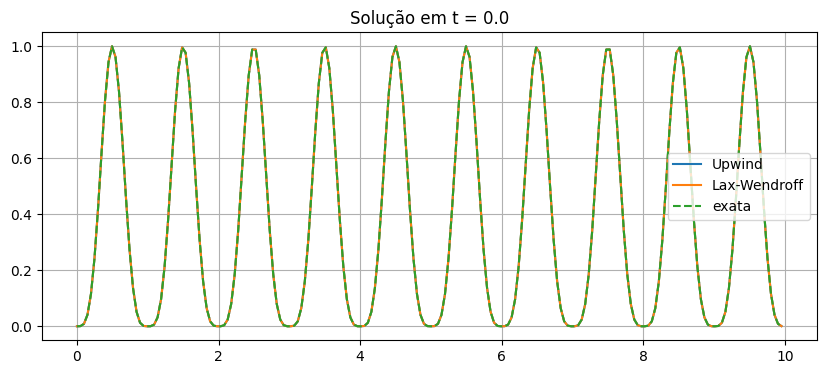

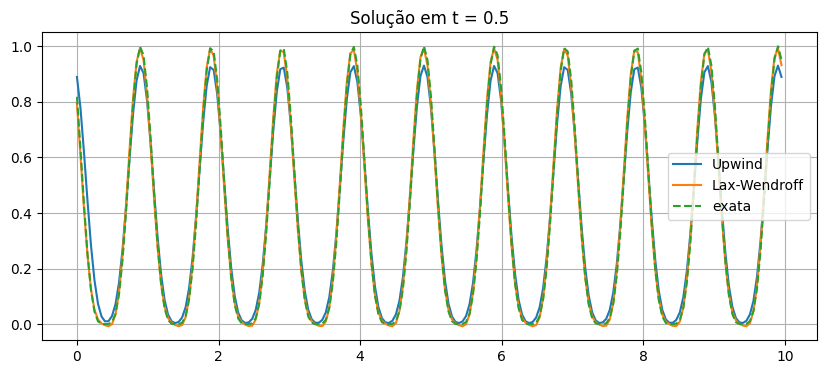

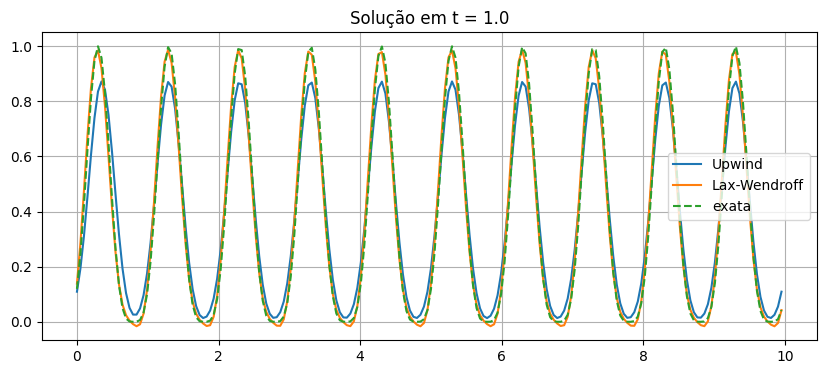

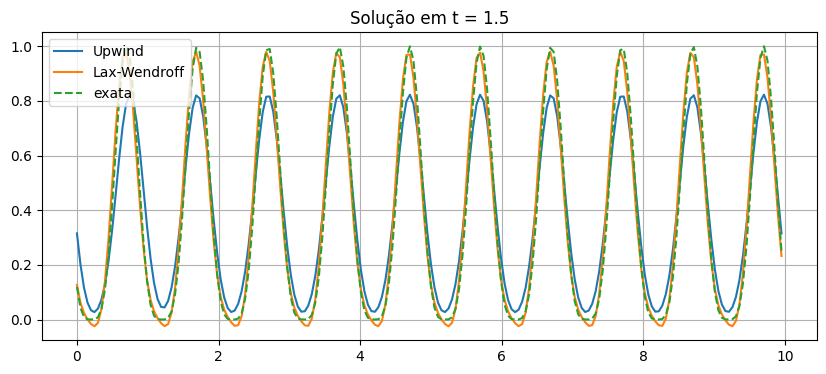

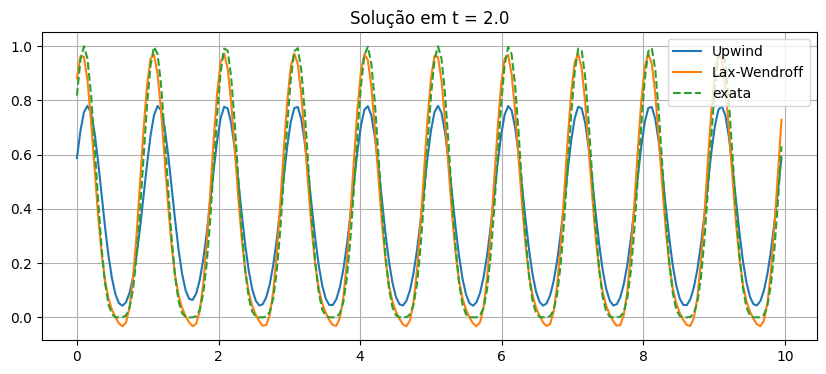

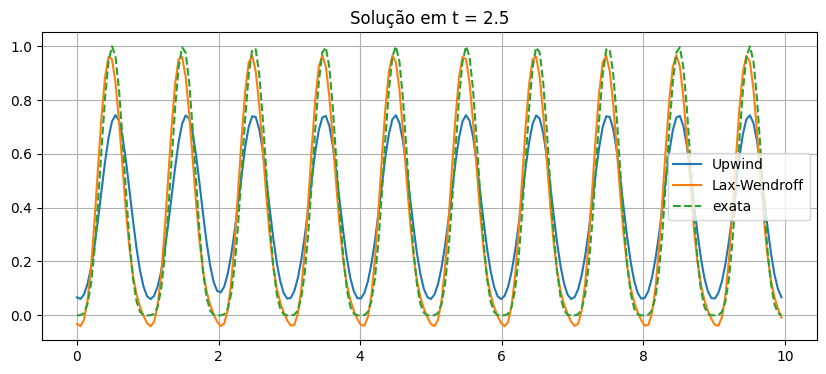

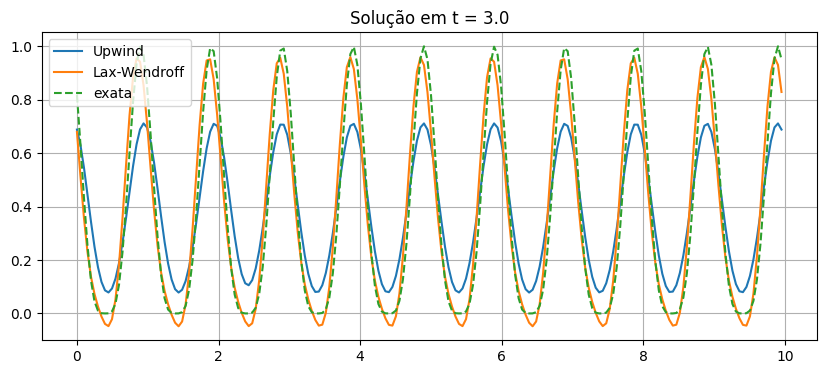

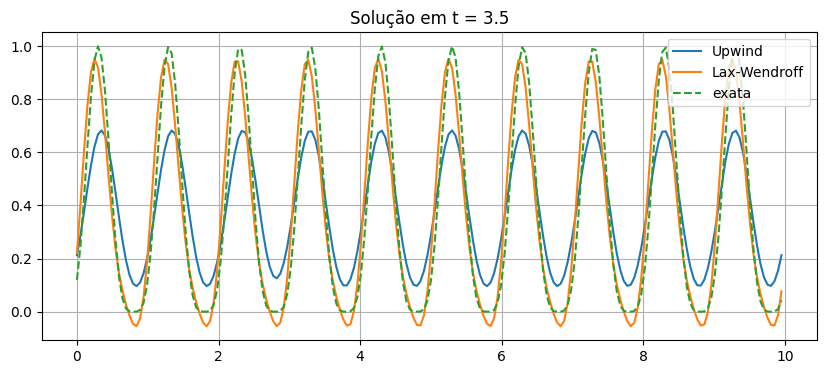

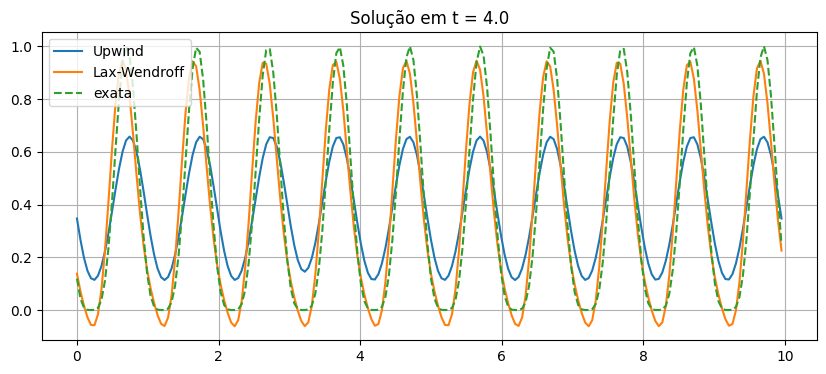

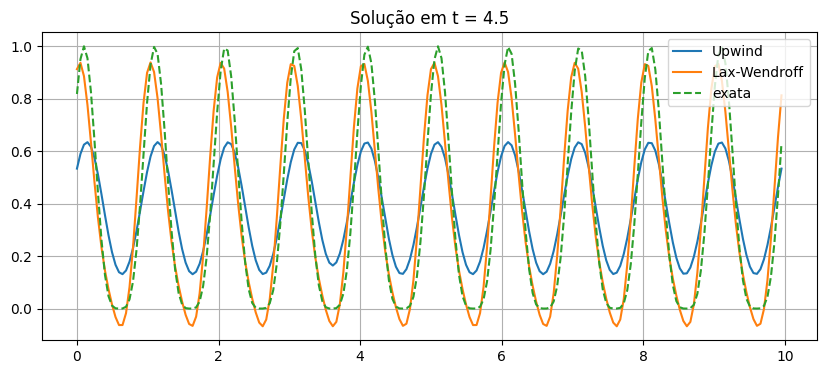

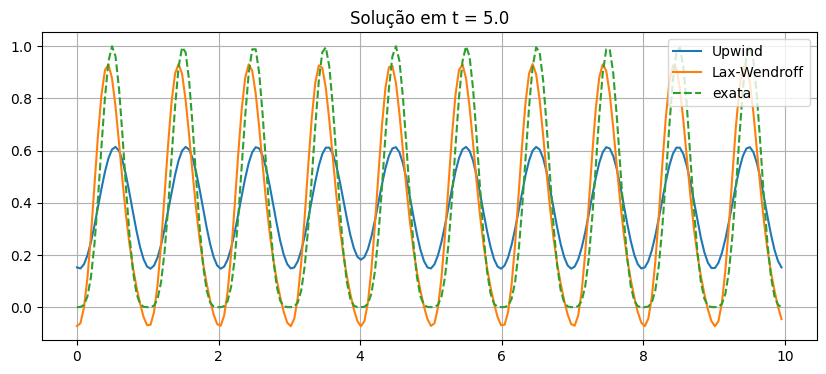

In [26]:
for i in range(len(t)):
    if i%10 == 0:
        plt.figure(figsize=(10,4))
        plt.plot(x, u[i,:], label = "Upwind")
        plt.plot(x,u2[i,:], label = 'Lax-Wendroff')
        plt.plot(x, solucao_exata(x,t[i],a), label='exata', linestyle='--')
        plt.title("Solução em t = {}".format(t[i]))
        plt.legend()
        plt.grid(True)
        plt.show()



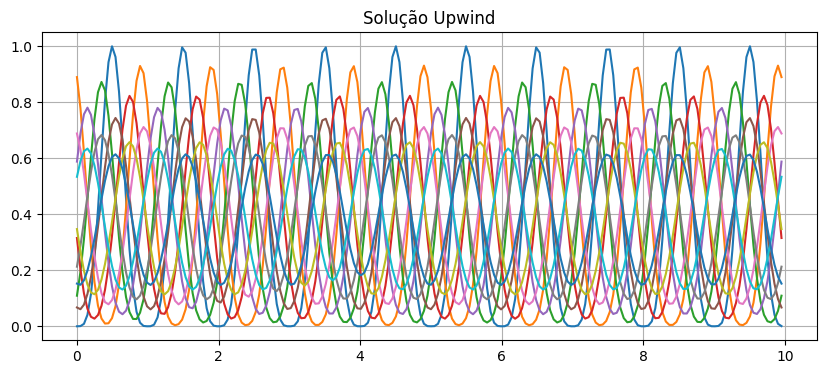

In [27]:
plt.figure(figsize=(10,4))
plt.title("Solução Upwind")

for i in range(len(t)):
    if i%10 == 0:
        plt.plot(x, u[i,:])
        # plt.plot(x,u2[i,:])
        # plt.plot(x, solucao_exata(x,t[i],a), label='exata', linestyle='--')

plt.grid(True)
plt.show()

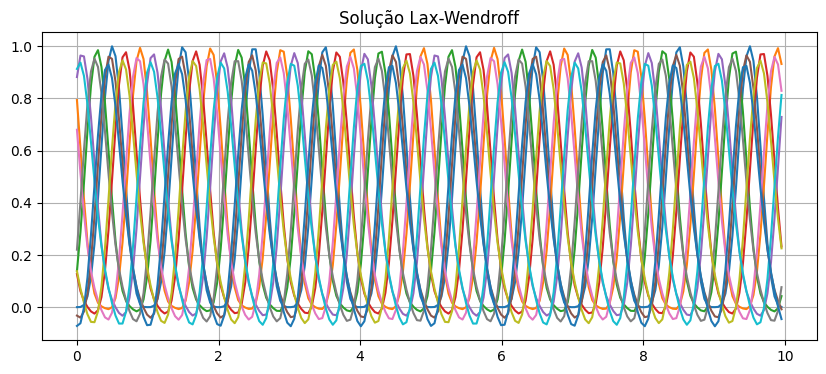

In [28]:
plt.figure(figsize=(10,4))
plt.title("Solução Lax-Wendroff")

for i in range(len(t)):
    if i%10 == 0:
        # plt.plot(x, u[i,:])
        plt.plot(x,u2[i,:])
        # plt.plot(x, solucao_exata(x,t[i],a), label='exata', linestyle='--')

plt.grid(True)
plt.show()


